In [1]:
!pip install -U transformers datasets evaluate accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.8/494.8 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.5/561.5 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# kalau perlu
!pip install -U "tensorflow>=2.11,<2.16"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 3.4 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled keras-3.8.0
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
  Attempting uninstall: ml-dtypes
    Found existing inst

In [3]:
import transformers
import datasets
import evaluate
import accelerate

print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Evaluate:", evaluate.__version__)
print("Accelerate:", accelerate.__version__)


2025-09-04 11:08:31.388865: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-04 11:08:31.388934: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-04 11:08:31.390970: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Transformers: 4.56.0
Datasets: 4.0.0
Evaluate: 0.4.5
Accelerate: 1.10.1


In [4]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/emotion-mining-on-comments-about-tom-lembong-case/sample_submission.csv
/kaggle/input/emotion-mining-on-comments-about-tom-lembong-case/train.csv
/kaggle/input/emotion-mining-on-comments-about-tom-lembong-case/test.csv


In [5]:
import pandas as pd

# load dataset
train = pd.read_csv("/kaggle/input/emotion-mining-on-comments-about-tom-lembong-case/train.csv")
test = pd.read_csv("/kaggle/input/emotion-mining-on-comments-about-tom-lembong-case/test.csv")
sample = pd.read_csv("/kaggle/input/emotion-mining-on-comments-about-tom-lembong-case/sample_submission.csv")

In [6]:
# cek 5 data teratas
print("Train Data:")
display(train.head())

print("\nTest Data:")
display(test.head())

Train Data:


,id_comment,source,text,label
0,UID0000,Instagram,makin dewasa makin sadar bahwa taktik pemerint...,SADNESS
1,UID0001,X / Twitter,Membuktikan hal yg benar di pengadilan itu mmg...,ANGER
2,UID0002,Instagram,RIP keadilan di Indonesia 🥀🥀🥀,SADNESS
3,UID0003,Instagram,"Dengan adanya pinjol, judol dan para rentenir ...",ANGER
4,UID0004,Instagram,@revandioctareza negri Morat marit🥀,SADNESS



Test Data:


,id_comment,source,text
0,UID5083,Instagram,Rusaknya tatanan hukum di negeri ini sejak mun...
1,UID5084,Instagram,sebaik ini padahal 😢
2,UID5085,Instagram,Orang ini akan di tagih di akhirat ingat ya hu...
3,UID5086,Instagram,Semangat Pak Tom
4,UID5087,Instagram,RIP keadilannn 💔🥀🥺


In [7]:
print("Kolom Train:", train.columns.values)
print("Kolom Test :", test.columns.values)
print("Shape Train:", train.shape)
print("Shape Test:", test.shape)

Kolom Train: ['id_comment' 'source' 'text' 'label']
Kolom Test : ['id_comment' 'source' 'text']
Shape Train: (5083, 4)
Shape Test: (1695, 3)


In [8]:
# drop kolom 'source' dari train dan test
train = train.drop(columns=['source'])
test = test.drop(columns=['source'])

In [9]:
# cek duplikat di train
dup_train = train.duplicated().sum()
print(f"Jumlah data duplikat di train: {dup_train}")

# cek duplikat di test
dup_test = test.duplicated().sum()
print(f"Jumlah data duplikat di test: {dup_test}")


Jumlah data duplikat di train: 0
Jumlah data duplikat di test: 0


In [10]:
print("Missing values (train):")
print(train.isnull().sum())

print("\nMissing values (test):")
print(test.isnull().sum())


Missing values (train):
id_comment    0
text          0
label         0
dtype: int64

Missing values (test):
id_comment    0
text          0
dtype: int64


Distribusi label (jumlah):
 label
SADNESS           1410
ANGER             1370
SUPPORT           1062
HOPE               994
DISAPPOINTMENT     247
Name: count, dtype: int64


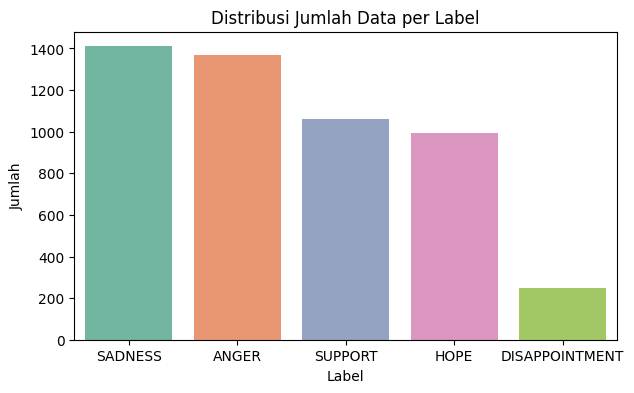

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# hitung distribusi
label_counts = train['label'].value_counts()
label_perc = train['label'].value_counts(normalize=True) * 100

print("Distribusi label (jumlah):\n", label_counts)

# visualisasi barplot
plt.figure(figsize=(7,4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="Set2")
plt.title("Distribusi Jumlah Data per Label")
plt.xlabel("Label")
plt.ylabel("Jumlah")
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


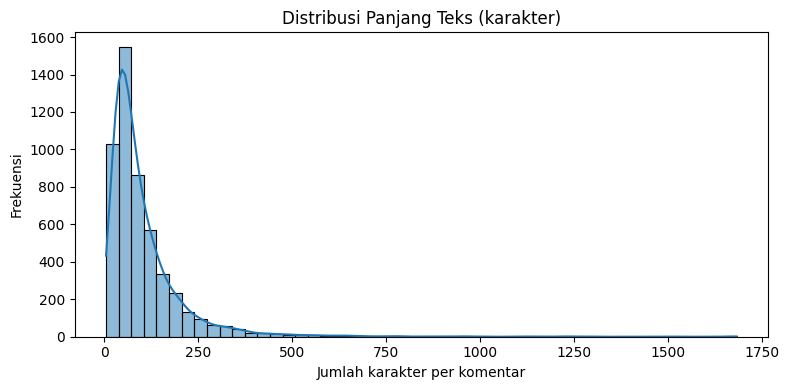

In [12]:
# Hanya plot distribusi panjang teks (berdasarkan jumlah karakter)
lengths = train['text'].astype(str).str.len()

plt.figure(figsize=(8, 4))
sns.histplot(lengths, bins=50, kde=True)
plt.title("Distribusi Panjang Teks (karakter)")
plt.xlabel("Jumlah karakter per komentar")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()


In [13]:
import nltk
import re


# Daftar slang words
SLANG_MAP = {
    "gk": "tidak", "ga": "tidak", "gak": "tidak", "tdk": "tidak", "nggak": "tidak",
    "bgt": "banget", "krn": "karena", "dr": "dari", "udh": "sudah", "udah": "sudah",
    "yg": "yang", "dgn": "dengan", "km": "kamu", "gue": "saya", "gw": "saya",
    "tp": "tapi", "pls": "tolong", "mksh": "terima kasih", "skrg": "sekarang", 
    "jd": "jadi", "ok": "oke", "okay": "oke", "dg": "dengan", "sdh": "sudah",
    "sy": "saya", "aku": "saya", "lo": "kamu", "lu": "kamu", "mu": "kamu",
    "nya": "dia", "nih": "ini", "sih": "saja", "deh": "saja", "dong": "saja",
    "ya": "iya", "yuk": "ayo", "sm": "sama", "pd": "pada", "utk": "untuk",
    "aja": "saja", "aj": "saja", "tsb": "tersebut", "dpt": "dapat", "tlg": "tolong",
    "d": "di", "jd": "jadi", "lbh": "lebih", "bgm": "bagaimana", "bgmn": "bagaimana"
}


# MAPPING EMOJI KHUSUS UNTUK SETIAP KELAS EMOSI (dipertahankan)
EMOJI_MAPPING = {
    # SADNESS - komentar sedih atau prihatin
    '😢': ' [SEDIH] ', '😭': ' [SEDIH] ', '🥀': ' [SEDIH] ', 
    '💔': ' [SEDIH] ', '😔': ' [SEDIH] ', '😞': ' [KECEWA] ',
    '😓': ' [SEDIH] ', '😩': ' [SEDIH] ', '😫': ' [SEDIH] ',
    '☹': ' [SEDIH] ', '🙁': ' [SEDIH] ', '🥺': ' [SEDIH] ',
    
    # ANGER - komentar marah atau mengecam
    '😡': ' [MARAH] ', '😠': ' [MARAH] ', '🤬': ' [MARAH] ',
    '💢': ' [MARAH] ', '👿': ' [MARAH] ', '😤': ' [KESAL] ',
    
    # HOPE - komentar penuh harapan atau doa  
    '🙏': ' [HARAP] ', '🤲': ' [HARAP] ', '✨': ' [HARAP] ',
    '🌟': ' [HARAP] ', '🌠': ' [HARAP] ', '😇': ' [HARAP] ',
    
    # DISAPPOINTMENT - rasa kecewa atau frustrasi
    '😐': ' [KECEWA] ', '😕': ' [KECEWA] ', '😮': ' [KECEWA] ',
    '😯': ' [KECEWA] ', '😲': ' [KECEWA] ', '😳': ' [KECEWA] ',
    '🤔': ' [KECEWA] ', '😶': ' [KECEWA] ',
    
    # SUPPORT - dukungan atau semangat
    '❤': ' [DUKUNG] ', '❤️': ' [DUKUNG] ', '🔥': ' [DUKUNG] ',
    '💪': ' [DUKUNG] ', '🙌': ' [DUKUNG] ', '🎉': ' [DUKUNG] ',
    '🤝': ' [DUKUNG] ', '✊': ' [DUKUNG] ', '⭐': ' [DUKUNG] ',
    '🏆': ' [DUKUNG] ', '🥰': ' [DUKUNG] ', '💕': ' [DUKUNG] ',
    
    # EMOJI NETRAL/UMUM - default mapping
    '👍': ' [SETUJU] ', '👏': ' [SETUJU] ', '🌧': ' [SEDIH] ',
    '⛈': ' [SEDIH] ', '😅': ' [LEGA] ', '😂': ' [SENANG] ',
    '🤣': ' [SENANG] ', '😊': ' [SENANG] ', '😎': ' [SENANG] ',
    '🤗': ' [SENANG] ', '🤩': ' [SENANG] ', '🥳': ' [SENANG] ',
    '🤯': ' [TERKEJUT] ', '😍': ' [SENANG] ', '🤪': ' [SENANG] ',
    '😴': ' [BOSAN] ', '🤢': ' [JIJIK] ', '🤮': ' [JIJIK] ',
    '🤧': ' [SEDIH] ', '🥵': ' [SUSAH] ', '🥶': ' [SUSAH] ',
    '🥴': ' [BINGUNG] ', '😵': ' [BINGUNG] ', '🤠': ' [SENANG] '
}
def preprocess_text(text, keep_repeat=1):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    
    # Remove URLs, mentions, hashtags
    text = re.sub(r"http\S+|www.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)
    
    # Handle elongated words
    text = re.sub(r'(.)\1{2,}', r'\1' * keep_repeat, text)
    
    # Replace emojis with their emotion-specific labels
    for emoji, label in EMOJI_MAPPING.items():
        text = text.replace(emoji, label)
    
    # Normalize slang words
    words = text.split()
    words = [SLANG_MAP.get(word, word) for word in words]
    text = " ".join(words)
    
    text = re.sub(r"[^a-zA-Z0-9\s_\[\]]", " ", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

# Apply preprocessing
print("Memproses data training...")
train['clean_text'] = train['text'].apply(lambda x: preprocess_text(x, keep_repeat=1))
print("Memproses data test...")
test['clean_text'] = test['text'].apply(lambda x: preprocess_text(x, keep_repeat=1))

# Tampilkan contoh hasil preprocessing dengan fokus pada emoji
print("\nContoh hasil preprocessing (dengan emoji mapping):")
for i in range(5):
    print(f"Original: {train['text'].iloc[i]}")
    print(f"Cleaned: {train['clean_text'].iloc[i]}")
    print(f"Label: {train['label'].iloc[i]}")
    print("-" * 70)

# Cek distribusi emoji yang sudah diproses
print("\nEmoji patterns dalam clean_text:")
emoji_patterns = ['[SEDIH]', '[MARAH]', '[DUKUNG]', '[KECEWA]', 'emoji_cinta_dukung']
for pattern in emoji_patterns:
    count = train['clean_text'].str.contains(pattern).sum()
    print(f"{pattern}: {count} kemunculan")

Memproses data training...
Memproses data test...

Contoh hasil preprocessing (dengan emoji mapping):
Original: makin dewasa makin sadar bahwa taktik pemerintah semengerikan itu😢🥀
Cleaned: makin dewasa makin sadar bahwa taktik pemerintah semengerikan itu [SEDIH] [SEDIH]
Label: SADNESS
----------------------------------------------------------------------
Original: Membuktikan hal yg benar di pengadilan itu mmg syusah. Sebersih, sesopan pak Tom Lembong sj tanpa ampun masuk bui 8 bulan. NM masih mending msh bisa ngalor ngidul n berdandan syantik, kasar ma petugas dipengadilan pula😊
Cleaned: membuktikan hal yang benar di pengadilan itu mmg syusah sebersih sesopan pak tom lembong sj tanpa ampun masuk bui 8 bulan nm masih mending msh bisa ngalor ngidul n berdandan syantik kasar ma petugas dipengadilan pula [SENANG]
Label: ANGER
----------------------------------------------------------------------
Original: RIP keadilan di Indonesia 🥀🥀🥀
Cleaned: rip keadilan di indonesia [SEDIH]
Label: SADN

In [14]:
# OVERSAMPLING

from sklearn.utils import resample

print("Jumlah sample per kelas sebelum oversampling:")
print(train['label'].value_counts())

# Lakukan oversampling untuk semua kelas minoritas
max_samples = max(train['label'].value_counts())
train_dfs = []
for label in train['label'].unique():
    label_df = train[train['label'] == label].copy()
    
    if len(label_df) < max_samples:
        print(f"Oversampling kelas '{label}' dari {len(label_df)} menjadi {max_samples} samples")
        label_df = resample(label_df,
                           replace=True,
                           n_samples=max_samples,
                           random_state=42)
    train_dfs.append(label_df)

# Gabungkan kembali semua kelas
train_balanced = pd.concat(train_dfs)
train = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nJumlah sample per kelas SETELAH oversampling:")
print(train['label'].value_counts())

Jumlah sample per kelas sebelum oversampling:
label
SADNESS           1410
ANGER             1370
SUPPORT           1062
HOPE               994
DISAPPOINTMENT     247
Name: count, dtype: int64
Oversampling kelas 'ANGER' dari 1370 menjadi 1410 samples
Oversampling kelas 'HOPE' dari 994 menjadi 1410 samples
Oversampling kelas 'SUPPORT' dari 1062 menjadi 1410 samples
Oversampling kelas 'DISAPPOINTMENT' dari 247 menjadi 1410 samples

Jumlah sample per kelas SETELAH oversampling:
label
DISAPPOINTMENT    1410
SADNESS           1410
ANGER             1410
SUPPORT           1410
HOPE              1410
Name: count, dtype: int64


In [15]:

# LABEL ENCODING

# Mapping label
EMO_ORDER = ["SADNESS", "ANGER", "SUPPORT", "HOPE", "DISAPPOINTMENT"]  

# Validasi: pastikan semua label di train ada dan tidak ada label asing
assert set(train["label"].unique()) == set(EMO_ORDER), \
    f"Label tak cocok: {set(train['label'].unique()) ^ set(EMO_ORDER)}"

label2id = {lab: i for i, lab in enumerate(EMO_ORDER)}
id2label = {i: lab for lab, i in label2id.items()}
num_labels = len(EMO_ORDER)

train["label_id"] = train["label"].map(label2id).astype("int64")

print("Label mapping (harus sama dgn evaluator):", label2id)
# {'SADNESS': 0, 'ANGER': 1, 'SUPPORT': 2, 'HOPE': 3, 'DISAPPOINTMENT': 4}


Label mapping (harus sama dgn evaluator): {'SADNESS': 0, 'ANGER': 1, 'SUPPORT': 2, 'HOPE': 3, 'DISAPPOINTMENT': 4}


In [16]:
# TRAIN-VALIDATION SPLIT

from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

train_oversampled = train[['clean_text','label_id','label']].copy()
train_df, val_df = train_test_split(
    train_oversampled, 
    test_size=0.1, 
    random_state=42, 
    stratify=train_oversampled['label_id']
)

hf_train = Dataset.from_pandas(train_df.reset_index(drop=True))
hf_val   = Dataset.from_pandas(val_df.reset_index(drop=True))
ds = DatasetDict({"train": hf_train, "validation": hf_val})

print(f"\nTrain: {len(hf_train)} samples")
print(f"Validation: {len(hf_val)} samples")


Train: 6345 samples
Validation: 705 samples


In [17]:
# TOKENIZATION

from transformers import AutoTokenizer
model_name = "indolem/indobertweet-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

def tok(batch):
    return tokenizer(
        batch["clean_text"],
        truncation=True,
        padding=True,
        max_length=128
    )

tokenized_ds = ds.map(
    tok, batched=True,
    remove_columns=[c for c in ds["train"].column_names if c not in ["clean_text","label_id","label"]]
).rename_column("label_id", "labels")

tokenized_ds.set_format(type="torch", columns=["input_ids","attention_mask","labels"])

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/6345 [00:00<?, ? examples/s]

Map:   0%|          | 0/705 [00:00<?, ? examples/s]

In [18]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

def freeze_bert_except_last_n(model, n_last_layers=8, verbose=True):
    # Bekukan backbone
    for p in model.base_model.parameters():
        p.requires_grad = False
    # Buka N layer terakhir encoder
    encoder_layers = model.base_model.encoder.layer
    for layer in encoder_layers[-n_last_layers:]:
        for p in layer.parameters():
            p.requires_grad = True
    # Head tetap trainable
    for p in model.classifier.parameters():
        p.requires_grad = True
    if verbose:
        total, trainable = 0, 0
        for _, p in model.named_parameters():
            n = p.numel(); total += n; trainable += n if p.requires_grad else 0
        print(f"Total params: {total:,} | Trainable: {trainable:,} ({trainable/total:.2%})")

freeze_bert_except_last_n(model, n_last_layers=8, verbose=True)

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobertweet-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total params: 110,562,053 | Trainable: 56,706,821 (51.29%)


In [19]:
# TRAINING SETUP

from sklearn.metrics import f1_score, accuracy_score
import numpy as np
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer, EarlyStoppingCallback
import torch

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if torch.cuda.is_available() else None
)

training_args = TrainingArguments(
    output_dir="./indobertweet-emotion",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_steps=100,
    logging_dir="./logs",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1",
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
    report_to="none",
    seed=42,
)

# Pastikan ke GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Using device: {device}")

# Gunakan Trainer standard
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Using device: cuda


/tmp/ipykernel_19/4006799128.py:49: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [20]:
# Jalankan sekali kalau TF belum ada
!pip install -U tensorflow -q


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.6/620.6 MB 786.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.0/322.0 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 85.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-api-core 1.34.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<4.0.0dev,>=3.19.5, but you have protobuf 6.32.0 which is incompatible.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have p

In [21]:
# STEP 7: TRAINING

print("Memulai training...")
train_result = trainer.train()
metrics_val = trainer.evaluate()
print("Validation metrics:", metrics_val)

# === SIMPAN MODEL TERBAIK KE FOLDER HF ===
best_dir = "./indobertweet-emotion/best"
trainer.save_model(best_dir)            # simpan weights + config model
tokenizer.save_pretrained(best_dir)     # simpan tokenizer
print(f"Model disimpan di: {best_dir}")

# (opsional tapi dianjurkan) simpan sebagai safetensors
model.save_pretrained(best_dir, safe_serialization=True)

from transformers import TFAutoModelForSequenceClassification
import tensorflow as tf
from IPython.display import FileLink

# Bangun model TF dari folder HF yang barusan disimpan (konversi PT -> TF)
tf_model = TFAutoModelForSequenceClassification.from_pretrained(
    best_dir,
    from_pt=True
)

# ⬅️ Tambahkan 1 baris build di sini (agar shape terbentuk sebelum save_weights)
_ = tf_model(tokenizer("halo", return_tensors="tf", padding=True, truncation=True, max_length=128))


# Simpan WEIGHTS ke .h5
h5_path = "/kaggle/working/indobertweet_emotion.h5"
tf_model.save_weights(h5_path)
print("Weights .h5 disimpan di:", h5_path)
display(FileLink(h5_path))


# Classification report detail
from sklearn.metrics import classification_report
preds = trainer.predict(tokenized_ds["validation"])
y_true = preds.label_ids
y_pred = preds.predictions.argmax(axis=1)
print("\nClassification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=[id2label[i] for i in range(num_labels)],
    digits=4
))


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Memulai training...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.869600,0.707855,0.741844,0.740271
2,0.478400,0.466286,0.841135,0.836549
3,0.284500,0.358340,0.885106,0.883941
4,0.193800,0.349179,0.878014,0.875725
5,0.126700,0.349556,0.887943,0.886324


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

...

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All PyTorch model weights were used when initializing TFBertForSequenceClassification.

All the weights of TFBertForSequenceClassification were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.
TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


Weights .h5 disimpan di: /kaggle/working/indobertweet_emotion.h5


/kaggle/working/indobertweet_emotion.h5

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



Classification Report:
                precision    recall  f1-score   support

       SADNESS     0.8537    0.7447    0.7955       141
         ANGER     0.8264    0.8440    0.8351       141
       SUPPORT     0.9225    0.9291    0.9258       141
          HOPE     0.9110    0.9433    0.9268       141
DISAPPOINTMENT     0.9200    0.9787    0.9485       141

      accuracy                         0.8879       705
     macro avg     0.8867    0.8879    0.8863       705
  weighted avg     0.8867    0.8879    0.8863       705



In [22]:
from IPython.display import FileLink, FileLinks
display(FileLink("/kaggle/working/indobertweet_emotion.h5"))  # link langsung
display(FileLinks("/kaggle/working"))                         # daftar semua file; klik dari sini


/kaggle/working/indobertweet_emotion.h5

/kaggle/working/
  __notebook__.ipynb
  indobertweet_emotion.h5
/kaggle/working/indobertweet-emotion/best/
  tokenizer_config.json
  tokenizer.json
  special_tokens_map.json
  model.safetensors
  training_args.bin
  config.json
  vocab.txt
/kaggle/working/indobertweet-emotion/checkpoint-796/
  tokenizer_config.json
  tokenizer.json
  trainer_state.json
  optimizer.pt
  special_tokens_map.json
  scaler.pt
  model.safetensors
  training_args.bin
  rng_state.pth
  config.json
  vocab.txt
  scheduler.pt
/kaggle/working/indobertweet-emotion/checkpoint-995/
  tokenizer_config.json
  tokenizer.json
  trainer_state.json
  optimizer.pt
  special_tokens_map.json
  scaler.pt
  model.safetensors
  training_args.bin
  rng_state.pth
  config.json
  vocab.txt
  scheduler.pt

In [23]:
import shutil, os
zip_path = shutil.make_archive(
    "/kaggle/working/indobertweet_emotion_h5", "zip",
    "/kaggle/working", "indobertweet_emotion.h5"
)
from IPython.display import FileLink
display(FileLink(zip_path))


/kaggle/working/indobertweet_emotion_h5.zip

In [24]:
import shutil, os
zip_path = shutil.make_archive(
    "/kaggle/working/indobertweet_emotion_h5", "zip",
    "/kaggle/working", "indobertweet_emotion.h5"
)
from IPython.display import FileLink
display(FileLink(zip_path))


/kaggle/working/indobertweet_emotion_h5.zip

In [25]:
# =============================================================================
# STEP 8: PREDIKSI DAN SUBMISSION (LABEL ANGKA)
# =============================================================================

# Tokenize test set - HANYA gunakan clean_text, tidak perlu label_id
def tok_test(batch):
    return tokenizer(
        batch["clean_text"],
        truncation=True,
        padding=True,
        max_length=128
    )

# Buat dataset hanya dengan clean_text
test_dataset = Dataset.from_pandas(test[['clean_text']].copy())

# Tokenize
tokenized_test = test_dataset.map(
    tok_test, batched=True,
    remove_columns=['clean_text']
)
tokenized_test.set_format(type="torch", columns=["input_ids","attention_mask"])

# Prediksi
print("Melakukan prediksi pada test set...")
pred_out = trainer.predict(tokenized_test)
y_pred_test = pred_out.predictions.argmax(axis=1).astype(int)

# Pastikan mapping label ke angka sudah benar
print("Mapping label ke angka:")
for i in range(num_labels):
    print(f"{id2label[i]} -> {i}")

# Buat submission file dengan LABEL ANGKA
if 'sample' in globals():
    sub = sample.copy()
    id_col = [c for c in sub.columns if c.lower() in ("id", "id_comment", "uid")][0]
    label_col = [c for c in sub.columns if c.lower() in ("label", "labels")][0]
    
    # Pastikan test dataframe memiliki kolom id yang sama
    test_id_col = [c for c in test.columns if c.lower() in ("id", "id_comment", "uid")][0]
    
    pred_df = pd.DataFrame({id_col: test[test_id_col].tolist(), label_col: y_pred_test})
    sub = sub[[id_col]].merge(pred_df, how="left", on=id_col)
else:
    # Fallback jika tidak ada sample
    id_col = "id_comment" if "id_comment" in test.columns else test.columns[0]
    sub = pd.DataFrame({id_col: test[id_col].tolist(), "label": y_pred_test})

# Simpan
SUBMIT_PATH = "./submission.csv"
sub.to_csv(SUBMIT_PATH, index=False)
print(f"Submission file disimpan: {SUBMIT_PATH}")
print("\nPreview submission (dengan label angka):")
display(sub.head())

# Verifikasi bahwa label adalah angka
print("\nTipe data label:", sub['label'].dtype)
print("Contoh nilai label:", sub['label'].head().tolist())

from IPython.display import FileLink
FileLink("./submission.csv")

Map:   0%|          | 0/1695 [00:00<?, ? examples/s]

Melakukan prediksi pada test set...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Mapping label ke angka:
SADNESS -> 0
ANGER -> 1
SUPPORT -> 2
HOPE -> 3
DISAPPOINTMENT -> 4
Submission file disimpan: ./submission.csv

Preview submission (dengan label angka):


,id_comment,label
0,UID5083,1
1,UID5084,0
2,UID5085,0
3,UID5086,2
4,UID5087,0



Tipe data label: int64
Contoh nilai label: [1, 0, 0, 2, 0]


/kaggle/working/submission.csv